In [1]:
import numpy as np
import math
import json
import time
import statistics
import sys
import os
from IPython.display import HTML

from ipynb.fs.full.vis import visualize_trajectories, plot_static_trajectories

sys.path.append(os.path.abspath("../py"))

from forcemodel import IForceModel, GravityForce
from integrator import IIntegrator, SymplecticEuler, VelocityVerlet
from env import SolarSystemEnv, run_simulation, run_script_simulation, adjust_barycentric
from helpers import save_states, load_states

In [2]:
# Heliocentric model of the solar system
bodies = [
    # Masses (kg)
    np.array([
        1.9885e30,    # Sun
        3.3011e23,    # Mercury
        4.8675e24,    # Venus
        5.972e24,     # Earth
        6.4171e23,    # Mars
        1.898e27,     # Jupiter
        5.6834e26,    # Saturn
        8.6810e25,    # Uranus
        1.02413e26,   # Neptune
    ]),
    # Positions (x, y) in meters (approx semi-major axes on x-axis)
    np.array([
        [0.0,        0.0],        # Sun
        [5.791e10,   0.0],        # Mercury
        [1.082e11,   0.0],        # Venus
        [1.496e11,   0.0],        # Earth
        [2.279e11,   0.0],        # Mars
        [7.785e11,   0.0],        # Jupiter
        [1.433e12,   0.0],        # Saturn
        [2.872e12,   0.0],        # Uranus
        [4.495e12,   0.0],        # Neptune
    ]),
    # Velocities (vx, vy) in m/s (circular orbit approximation)
    np.array([
        [0.0,     0.0],       # Sun
        [0.0, 47870.0],       # Mercury
        [0.0, 35020.0],       # Venus
        [0.0, 29783.0],       # Earth
        [0.0, 24077.0],       # Mars
        [0.0, 13070.0],       # Jupiter
        [0.0, 9690.0],        # Saturn
        [0.0, 6810.0],        # Uranus
        [0.0, 5430.0],        # Neptune
    ]),
    # Names
    np.array([
        "Sun",
        "Mercury",
        "Venus",
        "Earth",
        "Mars",
        "Jupiter",
        "Saturn",
        "Uranus",
        "Neptune",
    ]),
    # Colors (reasonable defaults for visualization)
    np.array([
        "orange",        # Sun
        "gray",          # Mercury
        "goldenrod",     # Venus
        "blue",          # Earth
        "red",           # Mars
        "darkgoldenrod", # Jupiter
        "green",         # Saturn
        "lightblue",     # Uranus
        "darkblue",     # Neptune
    ]),
]
bodies = adjust_barycentric(bodies)

COM position: [-3.79465155e-08  0.00000000e+00]
Total momentum: [ 0.00000000e+00 -8.23314307e+15]


In [3]:
dt=500 
n_steps=100000

In [4]:
n_runs = 10
runtimes = []

states = None

for i in range(n_runs):
    start = time.perf_counter()

    result = run_simulation(GravityForce,VelocityVerlet, bodies,dt=dt,n_steps=n_steps,records_len=500)

    end = time.perf_counter()
    elapsed = end - start
    runtimes.append(elapsed)

    print(f"Run {i+1}: {elapsed:.6f} seconds")

    # Save only the last run result
    if i == n_runs - 1:
        states = result

mean_time = statistics.mean(runtimes)
print(f"\nMean execution time over {n_runs} runs: {mean_time:.6f} seconds")
states = run_simulation(GravityForce, VelocityVerlet, bodies, dt=dt, n_steps=n_steps, records_len=500)


Run 1: 8.175150 seconds
Run 2: 3.819603 seconds
Run 3: 3.845859 seconds
Run 4: 3.891561 seconds
Run 5: 3.928988 seconds
Run 6: 3.897932 seconds
Run 7: 3.806609 seconds
Run 8: 3.819765 seconds
Run 9: 3.899038 seconds
Run 10: 3.885785 seconds

Mean execution time over 10 runs: 4.297029 seconds


In [5]:
scale=1.0/1.496e11
centre_body="Sun"
xlim=(-1.0, 1.0)
ylim=(-1.0, 1.0)

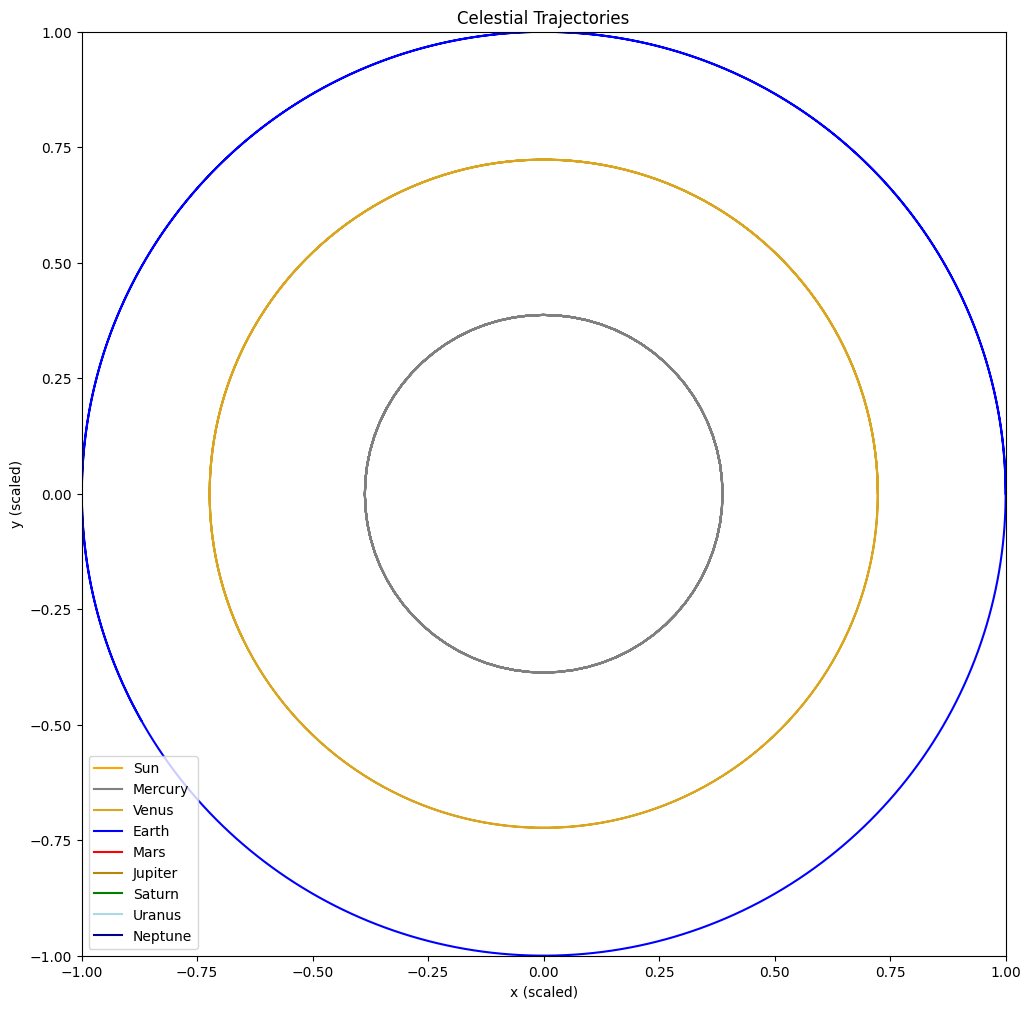

In [6]:
plot_static_trajectories(states=states, body_names=bodies[3], colors=bodies[4], scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim)

In [7]:
#anim = visualize_trajectories(states=states, body_names=bodies[3], colors=bodies[4], interval=20, scale=scale, centre_body=centre_body, xlim=xlim, ylim=ylim, save_path="geostationaryfling.gif")
#HTML(anim.to_jshtml())